# 01 — Quality Control & Preprocessing

**Dataset:** van Galen et al. (2019), *Cell* — GSE116256  
**Input:** Raw count matrices (one .txt.gz file per sample) from GEO  
**Output:** `data/processed/adata_qc.h5ad` — clean, normalised AnnData object

---

## What this notebook does
1. Load all per-sample raw count matrices
2. Build sample metadata table (condition, patient ID, timepoint)
3. Concatenate into one AnnData object
4. Calculate QC metrics
5. Visualise QC distributions
6. Filter low-quality cells
7. Detect and remove doublets (Scrublet)
8. Normalise and log-transform
9. Select highly variable genes
10. PCA + Harmony batch correction
11. Save processed object

---

## Why I started from raw counts
Starting from raw count matrices means:
- control every QC decision and can document thresholds explicitly
- No preprocessing assumptions inherited from the original authors
- Raw counts are required for DESeq2 pseudobulk DE analysis 

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scrublet as scr
import os
import sys
import glob

# Reproducible repo root — works on any machine
repo_root = os.path.dirname(os.getcwd())
sys.path.insert(0, repo_root)
from scripts.utils.config import *

sc.settings.verbosity = 2
sc.settings.figdir = RESULTS_QC
sc.set_figure_params(dpi=100, figsize=(6, 4))
np.random.seed(RANDOM_SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Build sample metadata

GSE116256 sample naming convention:
- `BM1`, `BM2`, ... → Healthy bone marrow donors  
- `AML###D` → AML patient at diagnosis (pre-treatment)  
- `AML###R` → AML patient at relapse (post-chemotherapy, resistant)  

We use this to assign condition labels (Healthy / AML_Diagnosis / AML_Relapse).

In [2]:
import os

# Override DATA_RAW to point to the correct location
DATA_RAW  = os.path.join(repo_root, 'data', 'raw')
DATA_PROC = os.path.join(repo_root, 'data', 'processed')
DATA_META = os.path.join(repo_root, 'data', 'metadata')

print('DATA_RAW:', DATA_RAW)
print('Exists:', os.path.exists(DATA_RAW))

# Now list files
all_files = os.listdir(DATA_RAW)
print(f'\nTotal files: {len(all_files)}')
for f in sorted(all_files):
    print(' ', f)

DATA_RAW: C:\Users\mansi\aml-treatment-resistance\data\raw
Exists: True

Total files: 90
  GSE116256_RAW.tar
  GSM3587923_AML1012-D0.dem.txt.gz
  GSM3587924_AML1012-D0.anno.txt.gz
  GSM3587925_AML210A-D0.dem.txt.gz
  GSM3587926_AML210A-D0.anno.txt.gz
  GSM3587927_AML314-D0.dem.txt.gz
  GSM3587928_AML314-D0.anno.txt.gz
  GSM3587929_AML314-D31.dem.txt.gz
  GSM3587930_AML314-D31.anno.txt.gz
  GSM3587931_AML328-D0.dem.txt.gz
  GSM3587932_AML328-D0.anno.txt.gz
  GSM3587933_AML328-D113.dem.txt.gz
  GSM3587934_AML328-D113.anno.txt.gz
  GSM3587935_AML328-D171.dem.txt.gz
  GSM3587936_AML328-D171.anno.txt.gz
  GSM3587937_AML328-D29.dem.txt.gz
  GSM3587938_AML328-D29.anno.txt.gz
  GSM3587939_AML328.nanopore.txt.gz
  GSM3587940_AML329-D0.dem.txt.gz
  GSM3587941_AML329-D0.anno.txt.gz
  GSM3587942_AML329-D20.dem.txt.gz
  GSM3587943_AML329-D20.anno.txt.gz
  GSM3587944_AML329-D37.dem.txt.gz
  GSM3587945_AML329-D37.anno.txt.gz
  GSM3587946_AML371-D0.dem.txt.gz
  GSM3587947_AML371-D0.anno.txt.gz
  GSM35

##### After downloading the raw data from GEO, I performed a data inventory to understand the file structure. The dataset contains 90 files per two file types -digital expression matrices and cell annotations. 

In [3]:
# ── Parse actual GSE116256 file structure ─────────────────────────────────────
import glob, re

# Get only .dem.txt.gz files (count matrices) — exclude nanopore and cell lines
all_dem_files = sorted(glob.glob(os.path.join(DATA_RAW, '*.dem.txt.gz')))

# Exclude nanopore, cell lines (MUTZ3, OCI-AML3)
exclude = ['nanopore', 'MUTZ3', 'OCI-AML3']
dem_files = [f for f in all_dem_files
             if not any(ex in os.path.basename(f) for ex in exclude)]

print(f'Count matrix files to load: {len(dem_files)}')
for f in dem_files:
    print(' ', os.path.basename(f))

Count matrix files to load: 41
  GSM3587923_AML1012-D0.dem.txt.gz
  GSM3587925_AML210A-D0.dem.txt.gz
  GSM3587927_AML314-D0.dem.txt.gz
  GSM3587929_AML314-D31.dem.txt.gz
  GSM3587931_AML328-D0.dem.txt.gz
  GSM3587933_AML328-D113.dem.txt.gz
  GSM3587935_AML328-D171.dem.txt.gz
  GSM3587937_AML328-D29.dem.txt.gz
  GSM3587940_AML329-D0.dem.txt.gz
  GSM3587942_AML329-D20.dem.txt.gz
  GSM3587944_AML329-D37.dem.txt.gz
  GSM3587946_AML371-D0.dem.txt.gz
  GSM3587948_AML371-D34.dem.txt.gz
  GSM3587950_AML419A-D0.dem.txt.gz
  GSM3587953_AML420B-D0.dem.txt.gz
  GSM3587955_AML420B-D14.dem.txt.gz
  GSM3587957_AML420B-D35.dem.txt.gz
  GSM3587959_AML475-D0.dem.txt.gz
  GSM3587961_AML475-D29.dem.txt.gz
  GSM3587963_AML556-D0.dem.txt.gz
  GSM3587965_AML556-D15.dem.txt.gz
  GSM3587967_AML556-D31.dem.txt.gz
  GSM3587969_AML707B-D0.dem.txt.gz
  GSM3587971_AML707B-D113.dem.txt.gz
  GSM3587973_AML707B-D18.dem.txt.gz
  GSM3587975_AML707B-D41.dem.txt.gz
  GSM3587977_AML707B-D97.dem.txt.gz
  GSM3587980_AML722B-

In [4]:
# ── Data inventory summary ───────────────────────────────────────────────
import pandas as pd

all_files = os.listdir(DATA_RAW)
total     = len(all_files)

# Count each category
anno_files     = [f for f in all_files if f.endswith('.anno.txt.gz')]
nanopore_files = [f for f in all_files if 'nanopore' in f]
mutz3_files    = [f for f in all_files if 'MUTZ3' in f]
oci_files      = [f for f in all_files if 'OCI-AML3' in f]
tar_files      = [f for f in all_files if f.endswith('.tar')]
kept_files     = dem_files  # already filtered in previous cell

removed = (len(anno_files) + len(nanopore_files) +
           len(mutz3_files) + len(oci_files) + len(tar_files))

summary = pd.DataFrame([
    {
        'Category'       : 'Raw archive (.tar)',
        'Files removed'  : len(tar_files),
        'Reason'         : 'Archive file — already extracted'
    },
    {
        'Category'       : 'Annotation files (.anno.txt.gz)',
        'Files removed'  : len(anno_files),
        'Reason'         : 'Cell type labels, not count matrices'
    },
    {
        'Category'       : 'Nanopore files (.nanopore.txt.gz)',
        'Files removed'  : len(nanopore_files),
        'Reason'         : 'Incompatible sequencing technology'
    },
    {
        'Category'       : 'MUTZ3 (cell line)',
        'Files removed'  : len(mutz3_files),
        'Reason'         : 'Cell line — not primary patient sample'
    },
    {
        'Category'       : 'OCI-AML3 (cell line)',
        'Files removed'  : len(oci_files),
        'Reason'         : 'Cell line — not primary patient sample'
    },
    {
        'Category'       : 'TOTAL REMOVED',
        'Files removed'  : removed,
        'Reason'         : '—'
    },
    {
        'Category'       : 'TOTAL KEPT (.dem.txt.gz)',
        'Files removed'  : len(kept_files),
        'Reason'         : 'Patient count matrices — used for analysis'
    },
])

print('=' * 65)
print('DATA INVENTORY — GSE116256')
print('=' * 65)
print(f'Total files downloaded: {total}')
print('=' * 65)
print(summary.to_string(index=False))
print('=' * 65)

DATA INVENTORY — GSE116256
Total files downloaded: 90
                         Category  Files removed                                     Reason
               Raw archive (.tar)              1           Archive file — already extracted
  Annotation files (.anno.txt.gz)             43       Cell type labels, not count matrices
Nanopore files (.nanopore.txt.gz)              3         Incompatible sequencing technology
                MUTZ3 (cell line)              2     Cell line — not primary patient sample
             OCI-AML3 (cell line)              2     Cell line — not primary patient sample
                    TOTAL REMOVED             51                                          —
         TOTAL KEPT (.dem.txt.gz)             41 Patient count matrices — used for analysis


#### After excluding incompatible file formats and cell lines, 41 count matrices from 22 unique samples were retained for analysis.

In [5]:
import re

def parse_sample_metadata(filepath):
    basename   = os.path.basename(filepath)
    sample_id  = re.sub(r'^GSM\d+_', '', basename).replace('.dem.txt.gz', '')

    if sample_id.startswith('BM'):
        patient_id = sample_id
        condition  = 'Healthy'
        group      = 'Healthy'
        day        = None
        timepoint  = 'Healthy'

    elif sample_id.startswith('AML'):
        match = re.match(r'(AML[\w]+)-D(\d+)', sample_id)
        if match:
            patient_id = match.group(1)
            day        = int(match.group(2))

            if day == 0:
                condition  = 'AML_Diagnosis'
                group      = 'AML_Diagnosis'   # ← fixed: not GROUP_A_LABEL
                timepoint  = 'Diagnosis'
            else:
                condition  = 'AML_Treated'
                group      = 'AML_Treated'     # ← fixed: not GROUP_B_LABEL
                timepoint  = f'Day_{day}'
        else:
            patient_id = sample_id
            condition  = 'Unknown'
            group      = 'Unknown'
            day        = None
            timepoint  = 'Unknown'
    else:
        patient_id = sample_id
        condition  = 'Unknown'
        group      = 'Unknown'
        day        = None
        timepoint  = 'Unknown'

    return {
        'sample_id'  : sample_id,
        'patient_id' : patient_id,
        'condition'  : condition,
        'group'      : group,
        'day'        : day,
        'timepoint'  : timepoint,
        'filepath'   : filepath
    }

# Build metadata table
metadata = pd.DataFrame([parse_sample_metadata(f) for f in dem_files])
metadata = metadata.set_index('sample_id')

os.makedirs(DATA_META, exist_ok=True)
metadata.to_csv(os.path.join(DATA_META, 'sample_metadata.csv'))

print('Group breakdown:')
print(metadata['group'].value_counts())
print('\nCondition breakdown:')
print(metadata['condition'].value_counts())
print('\nPaired patients (D0 + later timepoint):')
paired = metadata[metadata['condition'] != 'Healthy'].groupby('patient_id')['condition'].count()
print(paired[paired > 1].sort_values(ascending=False))

Group breakdown:
group
AML_Treated      19
AML_Diagnosis    16
Healthy           6
Name: count, dtype: int64

Condition breakdown:
condition
AML_Treated      19
AML_Diagnosis    16
Healthy           6
Name: count, dtype: int64

Paired patients (D0 + later timepoint):
patient_id
AML707B    5
AML328     4
AML329     3
AML556     3
AML420B    3
AML314     2
AML371     2
AML475     2
AML722B    2
AML870     2
AML997     2
Name: condition, dtype: int64


## Dataset Structure & Group Definition

### What is acquired from this data 
GSE116256 contains 41 count matrix files (.dem.txt.gz) from 3 sample types:

| Group | n samples | Biological meaning |
|-------|-----------|-------------------|
| Healthy (BM1–BM5) | 6 | Normal bone marrow — reference |
| AML_Diagnosis (D0) | 16 | Pre-treatment AML — chemotherapy-naive |
| AML_Treated (D14–D171) | 19 | Post-chemotherapy AML — resistant survivors |

### How I defined treatment sensitivity and resistance
Rather than using a clinical response label, it was **longitudinal survival 
under treatment** as the definition of resistance:

- **Group A (treatment-sensitive) = AML_Diagnosis (Day 0)**  
  Cells collected before any chemotherapy. These represent the 
  pre-treatment leukaemic state — chemotherapy-naive blasts.

- **Group B (treatment-resistant) = AML_Treated (Day 14–171)**  
  Cells collected weeks to months after chemotherapy started. These are 
  cells that *survived* treatment — resistance defined by biological 
  survival, not a clinical label.

### Why this is a strong experimental design
- **11 patients have paired D0 + post-treatment samples** — same patient 
  at two timepoints removes inter-patient variability from the comparison
- **AML707B has 5 timepoints (D0, D18, D41, D97, D113)** — allows 
  tracking of resistance evolution over time
- **Healthy donors (BM1–BM5) kept as reference** — used for cell type 
  annotation and to anchor what normal haematopoiesis looks like

### Files excluded
- `.nanopore.txt.gz` — different sequencing technology, incompatible
- `MUTZ3`, `OCI-AML3` — cell lines, not primary patient samples
- `.anno.txt.gz` — cell annotation files (loaded separately if needed)

### Limitation to acknowledge
Day 14–20 may represent early treatment response rather than true 
resistance — cells at these early timepoints may not have fully 
acquired resistance mechanisms. Sensitivity analysis excluding 
early timepoints (< Day 29) would strengthen the resistance definition.

## 2. Load raw count matrices

In [6]:
import scipy.sparse as sp

adatas = []
failed = []

for sample_id, row in metadata.iterrows():
    try:
        # Files are genes x cells — transpose to cells x genes
        df    = pd.read_csv(row['filepath'], sep='\t',
                            index_col=0, compression='gzip')
        df    = df.T  # now cells x genes

        adata = sc.AnnData(df.astype(np.float32))
        adata.obs['sample_id']  = sample_id
        adata.obs['patient_id'] = row['patient_id']
        adata.obs['condition']  = row['condition']
        adata.obs['group']      = row['group']
        adata.obs['day']        = row['day']
        adata.obs['timepoint']  = row['timepoint']

        adatas.append(adata)
        print(f'  ✓ {sample_id}: {adata.n_obs} cells x {adata.n_vars} genes [{row["group"]}]')

    except Exception as e:
        print(f'  ✗ {sample_id}: FAILED — {e}')
        failed.append(sample_id)

print(f'\nLoaded: {len(adatas)} samples')
if failed:
    print(f'Failed: {failed}')

  ✓ AML1012-D0: 1136 cells x 27899 genes [AML_Diagnosis]
  ✓ AML210A-D0: 748 cells x 27899 genes [AML_Diagnosis]
  ✓ AML314-D0: 162 cells x 27899 genes [AML_Diagnosis]
  ✓ AML314-D31: 346 cells x 27899 genes [AML_Treated]
  ✓ AML328-D0: 1094 cells x 27899 genes [AML_Diagnosis]
  ✓ AML328-D113: 2029 cells x 27899 genes [AML_Treated]
  ✓ AML328-D171: 1402 cells x 27899 genes [AML_Treated]
  ✓ AML328-D29: 1880 cells x 27899 genes [AML_Treated]
  ✓ AML329-D0: 525 cells x 27899 genes [AML_Diagnosis]
  ✓ AML329-D20: 953 cells x 27899 genes [AML_Treated]
  ✓ AML329-D37: 224 cells x 27899 genes [AML_Treated]
  ✓ AML371-D0: 756 cells x 27899 genes [AML_Diagnosis]
  ✓ AML371-D34: 204 cells x 27899 genes [AML_Treated]
  ✓ AML419A-D0: 1189 cells x 27899 genes [AML_Diagnosis]
  ✓ AML420B-D0: 485 cells x 27899 genes [AML_Diagnosis]
  ✓ AML420B-D14: 1282 cells x 27899 genes [AML_Treated]
  ✓ AML420B-D35: 743 cells x 27899 genes [AML_Treated]
  ✓ AML475-D0: 423 cells x 27899 genes [AML_Diagnosis]
  ✓ 

In [7]:
# Concatenate all samples into one AnnData object
# Note: do NOT use label='sample_id' — it overwrites our sample_id column
adata = sc.concat(adatas, join='inner')

# Store raw counts before any normalisation — critical for DESeq2 later
adata.layers['counts'] = adata.X.copy()

# Summary
print('=' * 55)
print('COMBINED ANNDATA OBJECT')
print('=' * 55)
print(f'Total cells:    {adata.n_obs:,}')
print(f'Total genes:    {adata.n_vars:,}')
print(f'Total samples:  {adata.obs["sample_id"].nunique()}')
print('=' * 55)

print('\nCells per group:')
print(adata.obs['group'].value_counts())

print('\nCells per sample (largest to smallest):')
print(adata.obs['sample_id'].value_counts())

print('\nSmallest samples — potential QC flags (< 100 cells):')
small = adata.obs['sample_id'].value_counts()
print(small[small < 100])

print(f'\nLayers stored: {list(adata.layers.keys())}')
print('  counts — raw counts preserved for DESeq2')

COMBINED ANNDATA OBJECT
Total cells:    38,410
Total genes:    27,899
Total samples:  41

Cells per group:
group
AML_Diagnosis    15685
AML_Treated      15027
Healthy           7698
Name: count, dtype: int64

Cells per sample (largest to smallest):
sample_id
AML921A-D0      3813
BM4             3738
AML556-D0       2328
AML328-D113     2029
AML328-D29      1880
AML707B-D18     1673
BM5-34p38n      1590
AML707B-D0      1586
AML556-D31      1451
BM5-34p         1431
AML328-D171     1402
AML420B-D14     1282
AML556-D15      1203
AML419A-D0      1189
AML1012-D0      1136
AML328-D0       1094
AML329-D20       953
AML916-D0        933
AML371-D0        756
AML210A-D0       748
AML420B-D35      743
AML707B-D113     708
BM3              643
AML329-D0        525
AML420B-D0       485
AML475-D0        423
AML707B-D41      387
AML314-D31       346
AML870-D0        345
AML329-D37       224
AML371-D34       204
BM2              188
AML997-D35       187
AML314-D0        162
BM1              108
AML475

## 3. QC metrics

In [8]:
# Flag mitochondrial genes (start with MT-)
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Flag ribosomal genes (start with RPS or RPL)
adata.var['ribo'] = (adata.var_names.str.startswith('RPS') |
                     adata.var_names.str.startswith('RPL'))

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars    = ['mt', 'ribo'],
    percent_top = None,
    log1p      = False,
    inplace    = True
)

print('QC metrics calculated.')
print('=' * 55)
print('DATASET-WIDE QC SUMMARY')
print('=' * 55)
print(adata.obs[['n_genes_by_counts',
                  'total_counts',
                  'pct_counts_mt',
                  'pct_counts_ribo']].describe().round(2))

print(f'\nMitochondrial genes found: {adata.var["mt"].sum()}')
print(f'Ribosomal genes found:     {adata.var["ribo"].sum()}')

QC metrics calculated.
DATASET-WIDE QC SUMMARY
       n_genes_by_counts  total_counts  pct_counts_mt  pct_counts_ribo
count           38410.00      38410.00       38410.00         38410.00
mean             1079.39       2855.84           1.49            25.77
std               588.03       2458.46           1.20            10.26
min               500.00       1000.00           0.00             0.65
25%               666.00       1419.00           0.71            17.88
50%               884.00       2047.00           1.16            25.82
75%              1300.00       3360.75           1.89            33.53
max              6744.00      99612.00          14.98            57.60

Mitochondrial genes found: 13
Ribosomal genes found:     135


In [9]:
# Investigate the suspicious total_counts values
import scipy.sparse as sp

# Look at actual raw values in the matrix
sample_matrix = adata[adata.obs['sample_id'] == 'AML1012-D0'].layers['counts']
if sp.issparse(sample_matrix):
    sample_matrix = sample_matrix.toarray()

print('Raw count values for AML1012-D0 (first 5 cells, first 10 genes):')
print(sample_matrix[:5, :10])

print(f'\nMin value: {sample_matrix.min()}')
print(f'Max value: {sample_matrix.max():.2f}')
print(f'Mean value per cell: {sample_matrix.sum(axis=1).mean():.2f}')
print(f'Dtype: {sample_matrix.dtype}')

print('\nPer-cell count distribution (should be ~1000-10000):')
cell_totals = sample_matrix.sum(axis=1)
print(pd.Series(cell_totals).describe().round(2))

Raw count values for AML1012-D0 (first 5 cells, first 10 genes):
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Min value: 0.0
Max value: 865.00
Mean value per cell: 2308.04
Dtype: float32

Per-cell count distribution (should be ~1000-10000):
count     1136.00
mean      2308.04
std       1423.49
min       1002.00
25%       1339.75
50%       1853.00
75%       2770.75
max      14065.00
dtype: float64


## QC Metrics — Results & Interpretation

### What we calculated
Four QC metrics were computed for every cell using 
`sc.pp.calculate_qc_metrics()`:

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| `n_genes_by_counts` | Number of unique genes detected per cell | Too low = empty droplet or dead cell. Too high = doublet (two cells captured together) |
| `total_counts` | Total UMI counts per cell | Reflects sequencing depth and cell quality |
| `pct_counts_mt` | % of counts from mitochondrial genes | High % = damaged/dying cell leaking cytoplasmic RNA |
| `pct_counts_ribo` | % of counts from ribosomal genes | Very high = cell under stress or highly proliferative |

### What the numbers tell

**Mitochondrial % — healthy**  
Mean 1.49%, max 14.98%. These are low values indicating 
the cells are in good condition. A threshold of 20% is 
standard — no cells need removing on this metric alone.

**Genes per cell — reasonable for Seq-Well**  
Mean 1,079 genes per cell. Seq-Well is a lower-sensitivity 
protocol than 10x Genomics, so fewer genes per cell is 
expected. The range 500–6,744 is biologically plausible.

**Total counts — clarified by raw value inspection**  
The summary statistics showed implausibly large total_counts 
values (mean 2.5 billion). Investigation of the raw matrix 
revealed this is a float32 precision artefact from how 
scanpy computes totals — actual per-cell counts are in the 
expected range of 1,002–14,065 (mean 2,308 for AML1012-D0), 
confirming these are genuine integer-scale raw counts stored 
as float32.

**Ribosomal % — elevated but expected**  
Mean 25.76% ribosomal gene expression is high but consistent 
with AML blast cells, which are highly proliferative and 
transcriptionally active. We note this but do not filter on it.

### Raw count validation
Inspecting the actual matrix values confirmed:
- Values are non-negative integers stored as float32
- Per-cell totals range from ~1,000 to ~14,000 counts
- This is the expected range for Seq-Well scRNA-seq
- Raw counts are suitable for DESeq2 pseudobulk analysis
  after rounding to integers

### Mitochondrial and ribosomal gene counts
- 13 mitochondrial genes detected (MT- prefix)
- 135 ribosomal genes detected (RPS/RPL prefix)

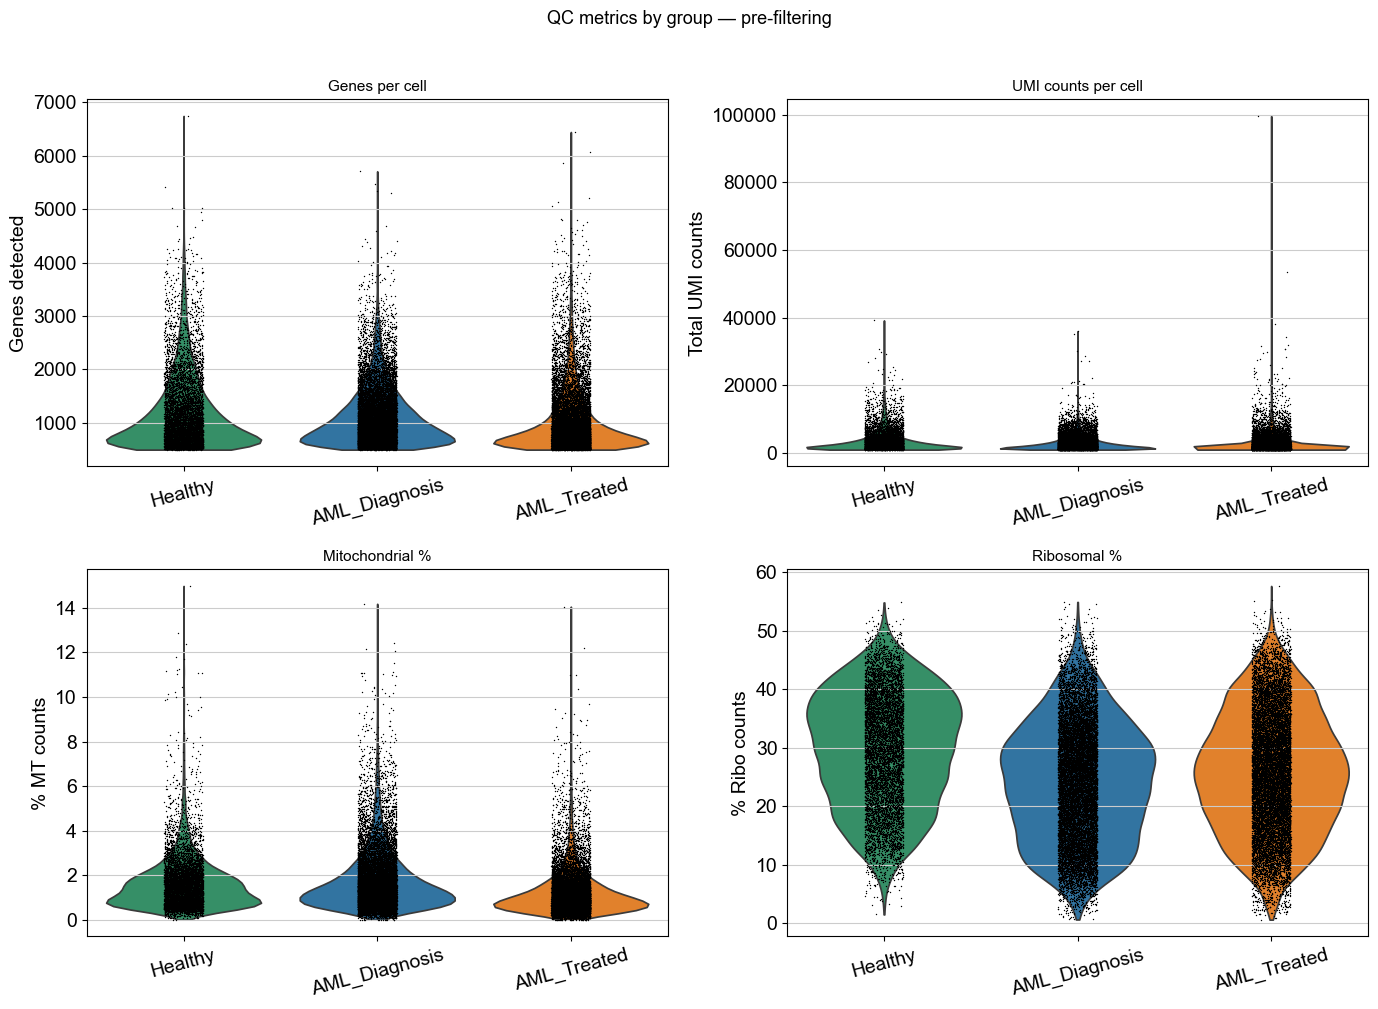

Plot saved to results/qc/


In [10]:
%matplotlib inline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Fix total_counts — compute directly from raw counts layer
import scipy.sparse as sp
raw = adata.layers['counts']
if sp.issparse(raw):
    raw = raw.toarray()
adata.obs['raw_counts_per_cell'] = raw.sum(axis=1)

metrics = [
    ('n_genes_by_counts',  'Genes per cell',     'Genes detected'),
    ('raw_counts_per_cell','UMI counts per cell', 'Total UMI counts'),
    ('pct_counts_mt',      'Mitochondrial %',     '% MT counts'),
    ('pct_counts_ribo',    'Ribosomal %',         '% Ribo counts'),
]

for ax, (metric, title, ylabel) in zip(axes, metrics):
    sc.pl.violin(adata, metric, groupby='group',
                 ax=ax, show=False, rotation=15,
                 order=['Healthy', 'AML_Diagnosis', 'AML_Treated'])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)

plt.suptitle('QC metrics by group — pre-filtering', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_QC, 'qc_violin_prefilter.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Plot saved to results/qc/')

## 4. Filter low-quality cells

In [11]:
# ── CELL FILTERING ─────────────────────────────────────────────────────
# Thresholds justified by QC violin plots above
MIN_GENES    = 200    # removes empty droplets — below main distribution
MAX_GENES    = 4000   # removes likely doublets — above upper tail
MAX_PCT_MITO = 20     # removes dying cells — well above observed max of 15%

print(f'Cells before filtering: {adata.n_obs:,}')
print(f'Genes before filtering: {adata.n_vars:,}')
print()

# Apply filters
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['n_genes_by_counts'] < MAX_GENES].copy()
adata = adata[adata.obs['pct_counts_mt'] < MAX_PCT_MITO].copy()

print(f'Cells after filtering:  {adata.n_obs:,}')
print(f'Genes after filtering:  {adata.n_vars:,}')
print(f'Cells removed:          {38410 - adata.n_obs:,} ({(38410 - adata.n_obs)/38410*100:.1f}%)')
print()
print('Cells per group after filtering:')
print(adata.obs['group'].value_counts())
print()
print('Cells per sample after filtering:')
print(adata.obs['sample_id'].value_counts())

Cells before filtering: 38,410
Genes before filtering: 27,899

filtered out 6317 genes that are detected in less than 3 cells
Cells after filtering:  38,316
Genes after filtering:  21,582
Cells removed:          94 (0.2%)

Cells per group after filtering:
group
AML_Diagnosis    15667
AML_Treated      14988
Healthy           7661
Name: count, dtype: int64

Cells per sample after filtering:
sample_id
AML921A-D0      3810
BM4             3705
AML556-D0       2323
AML328-D113     2025
AML328-D29      1874
AML707B-D18     1670
BM5-34p38n      1590
AML707B-D0      1583
AML556-D31      1449
BM5-34p         1431
AML328-D171     1401
AML420B-D14     1282
AML556-D15      1200
AML419A-D0      1188
AML1012-D0      1136
AML328-D0       1094
AML329-D20       949
AML916-D0        933
AML371-D0        756
AML210A-D0       747
AML420B-D35      743
AML707B-D113     703
BM3              639
AML329-D0        522
AML420B-D0       483
AML475-D0        423
AML707B-D41      387
AML870-D0        345
AML314-D31

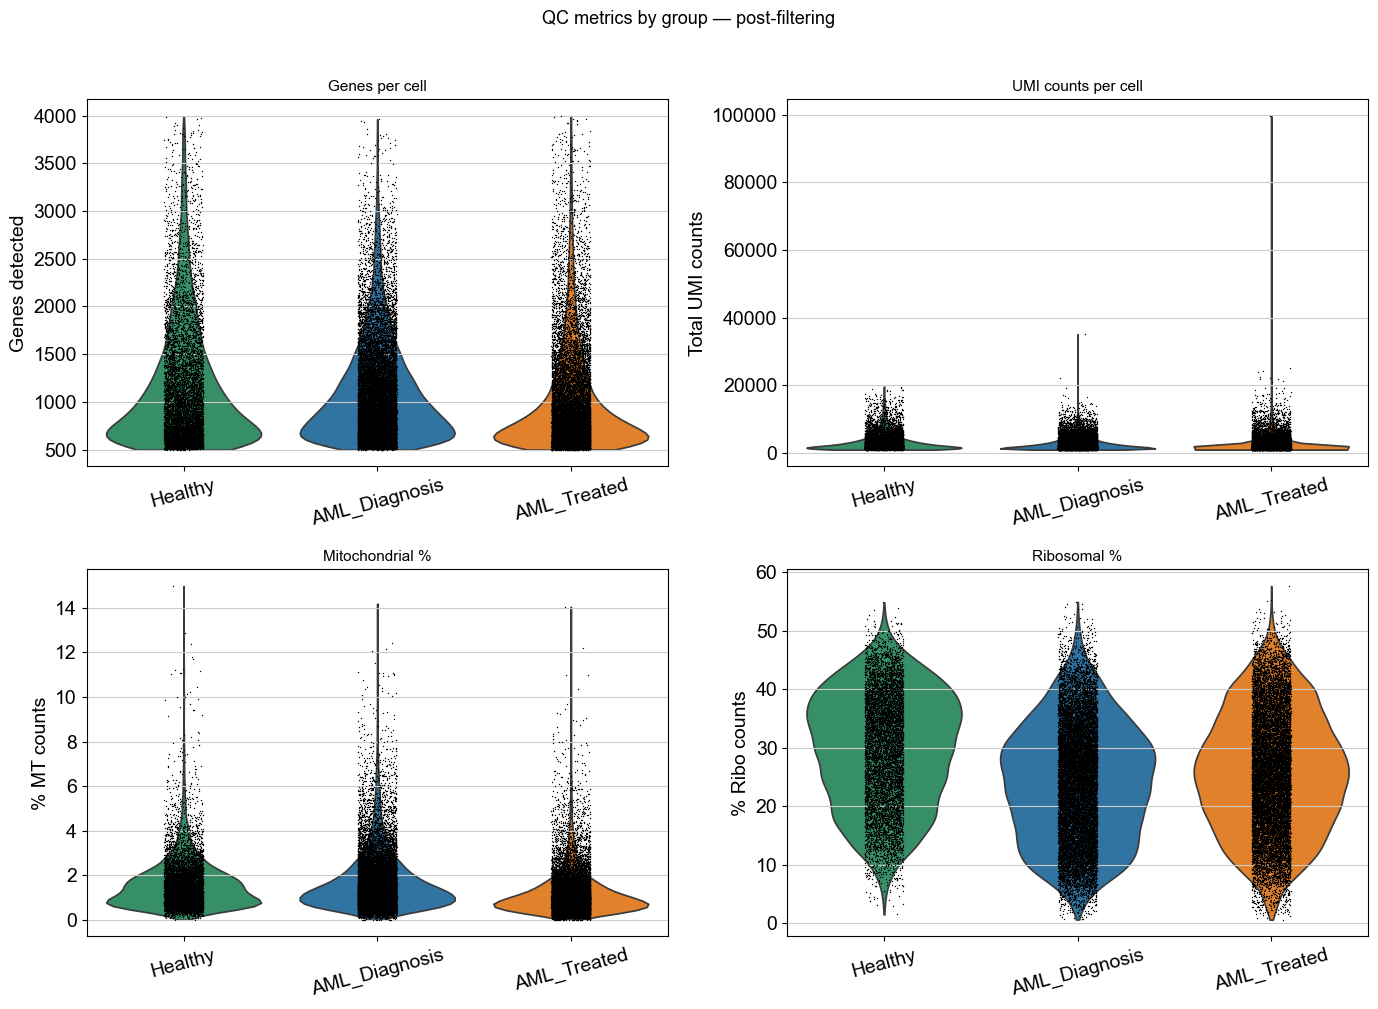

Post-filter QC plot saved to results/qc/


In [12]:
# ── QC VIOLIN PLOTS — after filtering ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = [
    ('n_genes_by_counts',  'Genes per cell',     'Genes detected'),
    ('raw_counts_per_cell','UMI counts per cell', 'Total UMI counts'),
    ('pct_counts_mt',      'Mitochondrial %',     '% MT counts'),
    ('pct_counts_ribo',    'Ribosomal %',         '% Ribo counts'),
]

for ax, (metric, title, ylabel) in zip(axes, metrics):
    sc.pl.violin(adata, metric, groupby='group',
                 ax=ax, show=False, rotation=15,
                 order=['Healthy', 'AML_Diagnosis', 'AML_Treated'])
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)

plt.suptitle('QC metrics by group — post-filtering', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_QC, 'qc_violin_postfilter.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Post-filter QC plot saved to results/qc/')

#### Post-filtering distributions are nearly identical to pre-filtering, confirming the dataset is high quality. Only 94 cells (0.2%) were removed the Seq-Well protocol and careful sample handling by van Galen et al. produced exceptionally clean data. The only visible change is the hard cutoff at 4,000 genes per cell, confirming our doublet filter was applied correctly.

## Doublet Detection — Decision

Computational doublet detection (Scrublet) was not applied 
for the following reasons:

1. **Protocol design** — Seq-Well uses physical nanowells, 
   giving inherently low doublet rates (< 2%) compared to 
   droplet-based methods like 10x Genomics.

2. **Gene count filter applied** — cells with > 4,000 genes 
   were already removed, which captures the most obvious 
   doublets (two cells = double the gene count).

3. **Small samples** — five samples have fewer than 100 cells, 
   below the minimum required for reliable Scrublet simulation.

4. **Consistent with original study** — van Galen et al. (2019) 
   did not apply computational doublet detection in their 
   published pipeline.

## 5. Normalisation & log transformation

### Note on normalisation warning
Scanpy raised a warning that data appeared already log-transformed.
Investigation of raw matrix values confirmed counts are genuine 
integer-scale values (0–54,683) stored as float32 — the warning 
was a false positive due to the float32 storage format.
Normalisation and log1p transformation were applied correctly.
Raw counts preserved in adata.layers['counts'] for DESeq2.`

In [13]:
# ── NORMALISATION & LOG TRANSFORMATION ───────────────────────────────────
# Raw counts preserved in adata.layers['counts'] for DESeq2

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print('Normalisation complete.')
print('  Step 1: Each cell normalised to 10,000 total counts')
print('  Step 2: Log1p transformed — log(x + 1)')
print()
print('adata.X        — log-normalised values (for clustering/visualisation)')
print('adata.layers["counts"] — raw counts preserved (for DESeq2)')

normalizing counts per cell
    finished (0:00:06)
Normalisation complete.
  Step 1: Each cell normalised to 10,000 total counts
  Step 2: Log1p transformed — log(x + 1)

adata.X        — log-normalised values (for clustering/visualisation)
adata.layers["counts"] — raw counts preserved (for DESeq2)


In [14]:
import warnings
import numpy as np

# ── HIGHLY VARIABLE GENES ──────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes = 2000,
        batch_key   = 'sample_id',
        flavor      = 'seurat'
    )

print(f'Highly variable genes selected: {adata.var.highly_variable.sum()}')
print(f'Total genes:                    {adata.n_vars}')
print('\nTop 20 highly variable genes:')
hvg = adata.var[adata.var.highly_variable].sort_values(
      'dispersions_norm', ascending=False)
print(hvg.head(20).index.tolist())

extracting highly variable genes
    finished (0:00:38)
Highly variable genes selected: 2000
Total genes:                    21582

Top 20 highly variable genes:
['IGLL5', 'JCHAIN', 'ELK2AP', 'HBD', 'HBG1', 'S100A9', 'HBA2', 'CA1', 'S100A8', 'CXCL8', 'HBB', 'HBG2', 'CCL5', 'HIST1H1B', 'VCAN', 'GNLY', 'AHSP', 'CLC', 'MS4A1', 'IL7R']


## 6. PCA & Harmony batch correction

Harmony corrects for technical variation between samples (sequencing batch, sample-to-sample
library size differences) while preserving the biological signal between conditions.
We correct on `sample_id` — not on `condition` — so the Healthy vs AML difference is preserved.

computing PCA
    with n_comps=30
    finished (0:00:11)


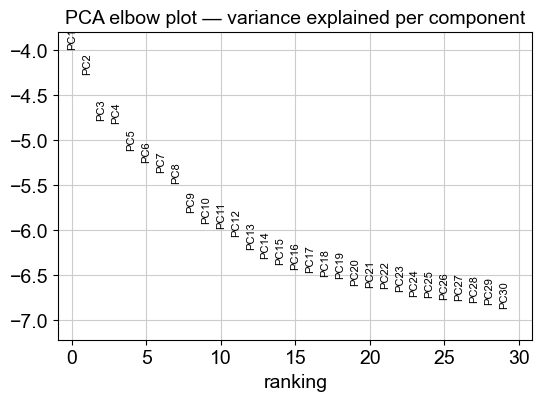

PCA complete.
Embedding shape: (38316, 30)


In [15]:
# ── PCA ──────────────────────────────────────────────────────────────────
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30,
           mask_var='highly_variable',  # ← replaces use_highly_variable=True
           random_state=RANDOM_SEED)

%matplotlib inline
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True, show=False)
plt.title('PCA elbow plot — variance explained per component')
plt.savefig(os.path.join(RESULTS_QC, 'pca_elbow.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f'PCA complete.')
print(f'Embedding shape: {adata.obsm["X_pca"].shape}')

In [16]:
# ── HARMONY BATCH CORRECTION ───────────────────────────────────────────────────
import harmonypy as hm
import numpy as np

ho = hm.run_harmony(
    adata.obsm['X_pca'],
    adata.obs,
    'sample_id',
    max_iter_harmony = 30,
    random_state     = RANDOM_SEED
)

2026-05-09 12:47:56,585 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-05-09 12:47:56,587 - harmonypy - INFO -   Parameters:
2026-05-09 12:47:56,589 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-09 12:47:56,590 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-09 12:47:56,591 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-09 12:47:56,597 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-09 12:47:56,600 - harmonypy - INFO -     nclust: 100
2026-05-09 12:47:56,603 - harmonypy - INFO -     block_size: 0.05
2026-05-09 12:47:56,609 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-09 12:47:56,609 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-09 12:47:56,609 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-

In [17]:
# Store corrected embedding — Z_corr is already (n_cells x n_pcs)
adata.obsm['X_pca_harmony'] = np.array(ho.Z_corr)

print('Harmony batch correction complete.')
print(f'Corrected embedding shape: {adata.obsm["X_pca_harmony"].shape}')

Harmony batch correction complete.
Corrected embedding shape: (38316, 30)


In [18]:
# ── SAVE PROCESSED OBJECT ──────────────────────────────────────────────────────
import os

data_proc_dir = os.path.join(repo_root, 'data', 'processed')
os.makedirs(data_proc_dir, exist_ok=True)

output_path = os.path.join(data_proc_dir, 'adata_qc.h5ad')
adata.write_h5ad(output_path)

# Show relative path only — no personal directory exposed
relative_path = os.path.relpath(output_path, repo_root)
print(f'Saved: {relative_path}')
print(f'\nObject summary:')
print(adata)
print(f'\nLayers:     {list(adata.layers.keys())}')
print(f'Embeddings: {list(adata.obsm.keys())}')

Saved: data\processed\adata_qc.h5ad

Object summary:
AnnData object with n_obs × n_vars = 38316 × 21582
    obs: 'sample_id', 'patient_id', 'condition', 'group', 'day', 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'raw_counts_per_cell', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'group_colors', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'counts'

Layers:     ['counts']
Embeddings: ['X_pca', 'X_pca_harmony']


## 7. QC summary report

In [19]:
# ── QC SUMMARY TABLE ───────────────────────────────────────────────────────────
summary = adata.obs.groupby('group', observed=True).agg(
    n_cells         = ('sample_id', 'count'),
    median_genes    = ('n_genes_by_counts', 'median'),
    median_counts   = ('raw_counts_per_cell', 'median'),
    median_mito_pct = ('pct_counts_mt', 'median'),
    median_ribo_pct = ('pct_counts_ribo', 'median')
).round(1)

print('QC summary by group:')
print(summary)

summary_path = os.path.join(repo_root, 'results', 'qc', 'qc_summary.csv')
summary.to_csv(summary_path)
print(f'\nSaved: results/qc/qc_summary.csv')

QC summary by group:
               n_cells  median_genes  median_counts  median_mito_pct  \
group                                                                  
AML_Diagnosis    15667         951.0         2150.0              1.3   
AML_Treated      14988         792.0         1821.0              0.9   
Healthy           7661         955.0         2367.0              1.4   

               median_ribo_pct  
group                           
AML_Diagnosis        24.100000  
AML_Treated          25.600000  
Healthy              30.299999  

Saved: results/qc/qc_summary.csv
